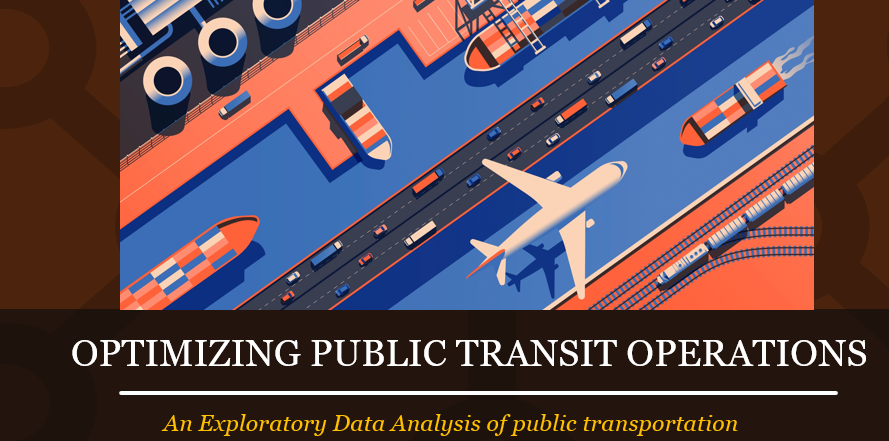

#### Project Introduction

MetroMove Transit Solutions operates public transportation services across multiple cities, supporting thousands of daily trips by bus, train, ferry, and tram. As urban mobility becomes more data-driven, MetroMove aims to use trip data to improve service efficiency, understand passenger behaviour, and deliver more reliable and affordable transportation experiences.

#### Problem Statement

Although MetroMove collects large volumes of trip data, the records are often messy, inconsistent, and incomplete. This makes it difficult to understand key patterns such as fare trends, passenger demand, trip duration, and the performance of different transport modes. Without proper analysis, the company may miss important insights that could improve operations and customer satisfaction.

#### Rationale for the Project

This project uses MetroMove’s trip data to uncover meaningful insights from raw transportation records. By cleaning, exploring, and visualizing the data, the project helps identify patterns in passenger usage, fare behaviour, transport mode performance, and trip efficiency. It also provides practical experience in data cleaning, exploratory data analysis, and communicating insights for real-world decision-making.

#### Data Description

The dataset contains trip-level records from MetroMove Transit Solutions, capturing information on transport mode, stations, trip timing, passenger volume, fare amount, and trip duration. Some columns contain missing values, inconsistent formatting, and text errors, making data cleaning an important step before analysis.

| Column | Description |
|-|-|
| `Trip_ID` | Unique identifier for each trip. |
| `Mode_of_Transport` | Type of transport used, such as Bus, Train, Ferry, or Tram. This column contains some inconsistencies. |
| `Departure_Station` | Station where the trip started. This column contains whitespace errors. |
| `Arrival_Station` | Station where the trip ended. This column contains inconsistent casing. |
| `Departure_Time` | Exact date and time when the trip departed. |
| `Passenger_Count` | Number of passengers on the trip. This column contains missing values. |
| `Fare_Amount` | Amount paid by passengers for the trip. This column contains missing values. |
| `Trip_Duration_Minutes` | Duration of the trip in minutes. This column contains missing values. |
| `Trip_Date` | Date on which the trip occurred. |
| `Day_of_Week` | Day of the week on which the trip occurred. |

### Importing libraries and loading the dataset

In [80]:
# importing libaries
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from collections import Counter


import warnings
warnings.filterwarnings('ignore')

In [8]:
# Load the dataset
data =pd.read_excel(r"C:\Users\hp\Desktop\10Alytics_Data Sc\Python_EDA Capstone\Public_Transport_Trips_EDA.xlsx")
data.head()

,Trip_ID,Mode_of_Transport,Departure_Station,Arrival_Station,Departure_Time,Passenger_Count,Fare_Amount,Trip_Duration_Minutes,Trip_Date,Day_of_Week,Unnamed: 10,Unnamed: 11
0,TRIP0001,FERRY,West End,airport,2024-01-01 06:00:00,21.0,4.343642,26.0,2024-01-01,Sunday,NaN,F
1,TRIP0002,Tram,North Station,Downtown,2024-01-01 06:01:00,46.0,20.673380,134.0,2024-01-01,Saturday,NaN,F
2,TRIP0003,bus,Central,North Station,2024-01-01 06:02:00,91.0,NaN,NaN,2024-01-01,Tuesday,NaN,F
3,TRIP0004,FERRY,Downtown,Central,2024-01-01 06:03:00,27.0,3.767487,NaN,2024-01-01,Sunday,NaN,F
4,TRIP0005,Ferry,Downtown,Central,2024-01-01 06:04:00,66.0,NaN,NaN,2024-01-01,Monday,NaN,F


### Insepcting the data

In [9]:
# Insepcting the data
data.columns

Index(['Trip_ID', 'Mode_of_Transport', 'Departure_Station', 'Arrival_Station',
       'Departure_Time', 'Passenger_Count', 'Fare_Amount',
       'Trip_Duration_Minutes', 'Trip_Date', 'Day_of_Week', 'Unnamed: 10',
       'Unnamed: 11'],
      dtype='object')

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Trip_ID                1000 non-null   object        
 1   Mode_of_Transport      1000 non-null   object        
 2   Departure_Station      1000 non-null   object        
 3   Arrival_Station        1000 non-null   object        
 4   Departure_Time         1000 non-null   datetime64[ns]
 5   Passenger_Count        900 non-null    float64       
 6   Fare_Amount            900 non-null    float64       
 7   Trip_Duration_Minutes  900 non-null    float64       
 8   Trip_Date              1000 non-null   datetime64[ns]
 9   Day_of_Week            1000 non-null   object        
 10  Unnamed: 10            0 non-null      float64       
 11  Unnamed: 11            299 non-null    object        
dtypes: datetime64[ns](2), float64(4), object(6)
memory usage: 93.9+

### Data Cleaning

In [11]:
#Dropping Irrelevant Columns
data.drop(["Unnamed: 10", "Unnamed: 11"], axis =1, inplace =True)
data.head()

,Trip_ID,Mode_of_Transport,Departure_Station,Arrival_Station,Departure_Time,Passenger_Count,Fare_Amount,Trip_Duration_Minutes,Trip_Date,Day_of_Week
0,TRIP0001,FERRY,West End,airport,2024-01-01 06:00:00,21.0,4.343642,26.0,2024-01-01,Sunday
1,TRIP0002,Tram,North Station,Downtown,2024-01-01 06:01:00,46.0,20.673380,134.0,2024-01-01,Saturday
2,TRIP0003,bus,Central,North Station,2024-01-01 06:02:00,91.0,NaN,NaN,2024-01-01,Tuesday
3,TRIP0004,FERRY,Downtown,Central,2024-01-01 06:03:00,27.0,3.767487,NaN,2024-01-01,Sunday
4,TRIP0005,Ferry,Downtown,Central,2024-01-01 06:04:00,66.0,NaN,NaN,2024-01-01,Monday


In [12]:
data['Mode_of_Transport'].value_counts() # inconsistents issue here

Mode_of_Transport
Bus      147
Tram     138
bus      137
train    123
Train    120
FERRY    119
Ferry    118
fErry     50
BUS       48
Name: count, dtype: int64

In [13]:
data['Mode_of_Transport'] =np.where(data['Mode_of_Transport'].isin(['bus','BUS']),'Bus',data['Mode_of_Transport'])
data['Mode_of_Transport'] =np.where(data['Mode_of_Transport'] == 'train','Train',data['Mode_of_Transport'])
data['Mode_of_Transport'] =np.where(data['Mode_of_Transport'].isin(['FERRY','fErry']),'Ferry',data['Mode_of_Transport'])

In [14]:
data['Mode_of_Transport'].value_counts() 

Mode_of_Transport
Bus      332
Ferry    287
Train    243
Tram     138
Name: count, dtype: int64

In [15]:
data['Departure_Station'].value_counts() # inconsistents issue here- empty space

Departure_Station
North Station    171
Downtown         167
West End         159
Central          158
Airport          157
South Point      138
 Central          50
Name: count, dtype: int64

In [16]:
data['Departure_Station'] =data['Departure_Station'].str.replace(" Central","Central")

In [17]:
data['Departure_Station'] =np.where(data['Departure_Station'].isin(['Central','Central']), 'Central',data['Departure_Station'])
data['Departure_Station'].value_counts()

Departure_Station
North Station    171
Downtown         167
West End         159
Central          158
Airport          157
South Point      138
Central           50
Name: count, dtype: int64

In [18]:
data['Departure_Station'].value_counts()

Departure_Station
North Station    171
Downtown         167
West End         159
Central          158
Airport          157
South Point      138
Central           50
Name: count, dtype: int64

In [19]:
data['Arrival_Station'].value_counts() # inconsistents issue here- airport/Airport

Arrival_Station
South Point      171
Downtown         168
West End         163
Airport          163
Central          160
North Station    125
airport           50
Name: count, dtype: int64

In [20]:
data['Arrival_Station'] =data['Arrival_Station'].str.replace("airport","Airport")
data['Arrival_Station'].value_counts()

Arrival_Station
Airport          213
South Point      171
Downtown         168
West End         163
Central          160
North Station    125
Name: count, dtype: int64

In [21]:
data['Day_of_Week'].value_counts() # No issue here

Day_of_Week
Sunday       167
Tuesday      147
Saturday     146
Monday       142
Friday       142
Wednesday    138
Thursday     118
Name: count, dtype: int64

In [22]:
data.head()

,Trip_ID,Mode_of_Transport,Departure_Station,Arrival_Station,Departure_Time,Passenger_Count,Fare_Amount,Trip_Duration_Minutes,Trip_Date,Day_of_Week
0,TRIP0001,Ferry,West End,Airport,2024-01-01 06:00:00,21.0,4.343642,26.0,2024-01-01,Sunday
1,TRIP0002,Tram,North Station,Downtown,2024-01-01 06:01:00,46.0,20.673380,134.0,2024-01-01,Saturday
2,TRIP0003,Bus,Central,North Station,2024-01-01 06:02:00,91.0,NaN,NaN,2024-01-01,Tuesday
3,TRIP0004,Ferry,Downtown,Central,2024-01-01 06:03:00,27.0,3.767487,NaN,2024-01-01,Sunday
4,TRIP0005,Ferry,Downtown,Central,2024-01-01 06:04:00,66.0,NaN,NaN,2024-01-01,Monday


In [23]:
data.isna().sum() #3 issues of missing values

Trip_ID                    0
Mode_of_Transport          0
Departure_Station          0
Arrival_Station            0
Departure_Time             0
Passenger_Count          100
Fare_Amount              100
Trip_Duration_Minutes    100
Trip_Date                  0
Day_of_Week                0
dtype: int64

In [24]:
#Let's address the issue of missing values using the median value
values = {"Passenger_Count":data['Passenger_Count'].median(),"Fare_Amount":data['Fare_Amount'].median(),"Trip_Duration_Minutes":data['Trip_Duration_Minutes'].median()}
data.fillna(values, inplace =True)
data.isna().sum()

Trip_ID                  0
Mode_of_Transport        0
Departure_Station        0
Arrival_Station          0
Departure_Time           0
Passenger_Count          0
Fare_Amount              0
Trip_Duration_Minutes    0
Trip_Date                0
Day_of_Week              0
dtype: int64

In [25]:
data.head()

,Trip_ID,Mode_of_Transport,Departure_Station,Arrival_Station,Departure_Time,Passenger_Count,Fare_Amount,Trip_Duration_Minutes,Trip_Date,Day_of_Week
0,TRIP0001,Ferry,West End,Airport,2024-01-01 06:00:00,21.0,4.343642,26.0,2024-01-01,Sunday
1,TRIP0002,Tram,North Station,Downtown,2024-01-01 06:01:00,46.0,20.673380,134.0,2024-01-01,Saturday
2,TRIP0003,Bus,Central,North Station,2024-01-01 06:02:00,91.0,25.403856,97.5,2024-01-01,Tuesday
3,TRIP0004,Ferry,Downtown,Central,2024-01-01 06:03:00,27.0,3.767487,97.5,2024-01-01,Sunday
4,TRIP0005,Ferry,Downtown,Central,2024-01-01 06:04:00,66.0,25.403856,97.5,2024-01-01,Monday


In [26]:
data.duplicated().sum()

np.int64(0)

### Data Explorations

In [27]:
data['Departure_Time'].max()

Timestamp('2024-01-01 22:39:00')

In [28]:
data['Departure_Time'].min()

Timestamp('2024-01-01 06:00:00')

In [29]:
data['Trip_Duration_Minutes'].max()

np.float64(179.0)

In [30]:
data['Trip_Duration_Minutes'].min()

np.float64(5.0)

### Descriptive Statiscs

In [31]:
data.describe() # we suspect outilers

,Departure_Time,Passenger_Count,Fare_Amount,Trip_Duration_Minutes,Trip_Date
count,1000,1000.000000,1000.000000,1000.000000,1000
mean,2024-01-01 14:19:30,49.039000,25.365053,94.593000,2024-01-21 08:03:50.400000
min,2024-01-01 06:00:00,1.000000,0.500576,5.000000,2024-01-01 00:00:00
25%,2024-01-01 10:09:45,28.000000,13.917364,55.000000,2024-01-11 00:00:00
50%,2024-01-01 14:19:30,48.000000,25.403856,97.500000,2024-01-21 00:00:00
75%,2024-01-01 18:29:15,70.000000,36.580122,132.250000,2024-02-01 00:00:00
max,2024-01-01 22:39:00,99.000000,49.945184,179.000000,2024-02-11 00:00:00
std,NaN,26.277709,13.721526,48.043673,NaN


In [32]:
data.describe(include=['object', 'bool']) # we suspect outilers

,Trip_ID,Mode_of_Transport,Departure_Station,Arrival_Station,Day_of_Week
count,1000,1000,1000,1000,1000
unique,1000,4,7,6,7
top,TRIP0001,Bus,North Station,Airport,Sunday
freq,1,332,171,213,167


### Univariate Analysis

#### Univariate Analysis for Categorical variables

In [33]:
data.head()

,Trip_ID,Mode_of_Transport,Departure_Station,Arrival_Station,Departure_Time,Passenger_Count,Fare_Amount,Trip_Duration_Minutes,Trip_Date,Day_of_Week
0,TRIP0001,Ferry,West End,Airport,2024-01-01 06:00:00,21.0,4.343642,26.0,2024-01-01,Sunday
1,TRIP0002,Tram,North Station,Downtown,2024-01-01 06:01:00,46.0,20.673380,134.0,2024-01-01,Saturday
2,TRIP0003,Bus,Central,North Station,2024-01-01 06:02:00,91.0,25.403856,97.5,2024-01-01,Tuesday
3,TRIP0004,Ferry,Downtown,Central,2024-01-01 06:03:00,27.0,3.767487,97.5,2024-01-01,Sunday
4,TRIP0005,Ferry,Downtown,Central,2024-01-01 06:04:00,66.0,25.403856,97.5,2024-01-01,Monday


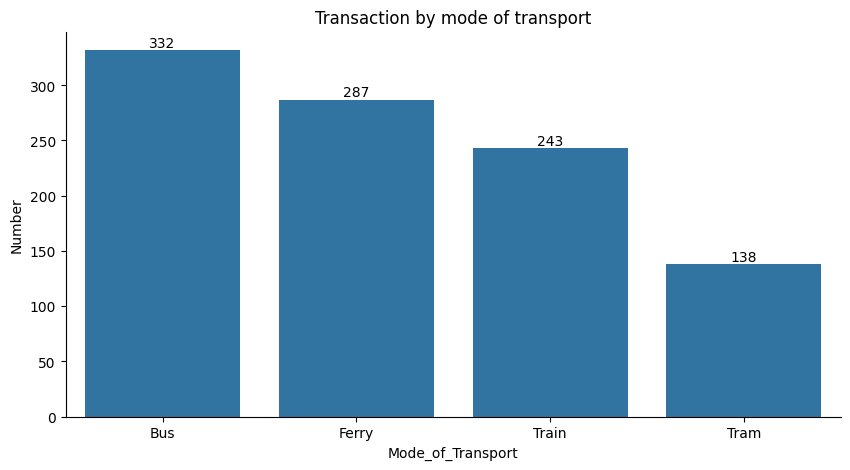

In [34]:
fig, ax =plt.subplots(figsize =(10, 5))

ax =sns.countplot(x =data['Mode_of_Transport'], order =data['Mode_of_Transport'].value_counts(ascending =False).index)
values =data['Mode_of_Transport'].value_counts(ascending =False).values
ax.bar_label(container =ax.containers[0], label =values)
plt.title("Transaction by mode of transport")
plt.ylabel("Number")
sns.despine();

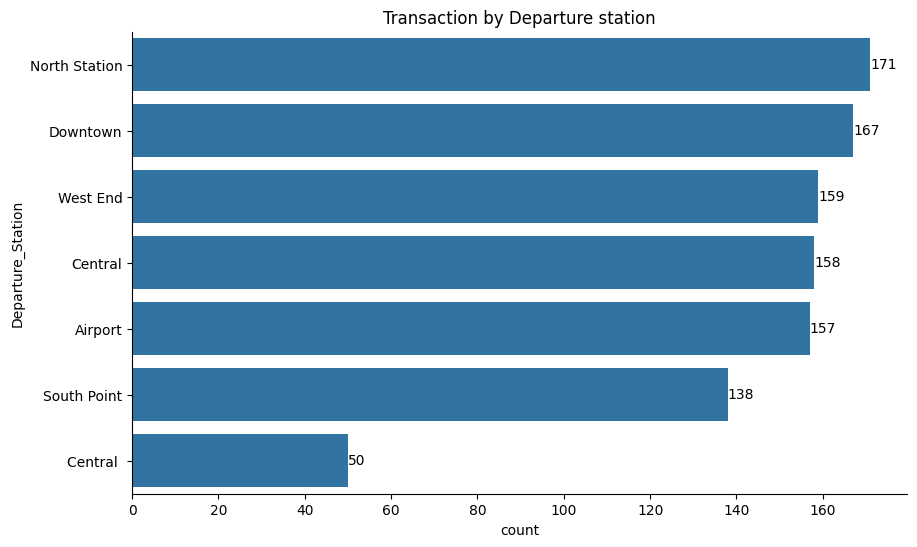

In [35]:
fig, ax =plt.subplots(figsize =(10,6))

ax =sns.countplot(y= data['Departure_Station'], order = data['Departure_Station'].value_counts(ascending =False).index)
values =data['Departure_Station'].value_counts(ascending =True).values
ax.bar_label(container =ax.containers[0], label =values)
plt.title("Transaction by Departure station")
sns.despine()

In [36]:
# There is an issue, the central appears twice. let's dea
data['Departure_Station'].value_counts()

Departure_Station
North Station    171
Downtown         167
West End         159
Central          158
Airport          157
South Point      138
Central           50
Name: count, dtype: int64

In [37]:
data['Departure_Station'] =data['Departure_Station'].str.strip()

In [38]:
data['Departure_Station'].value_counts()

Departure_Station
Central          208
North Station    171
Downtown         167
West End         159
Airport          157
South Point      138
Name: count, dtype: int64

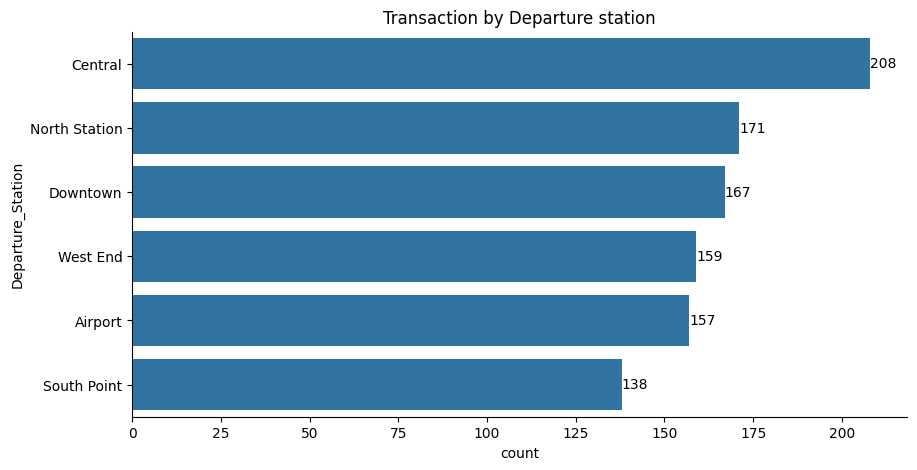

In [39]:
fig, ax =plt.subplots(figsize =(10,5))

ax =sns.countplot(y= data['Departure_Station'], order = data['Departure_Station'].value_counts(ascending =False).index)
values =data['Departure_Station'].value_counts(ascending =True).values
ax.bar_label(container =ax.containers[0], label =values)
plt.title("Transaction by Departure station")
sns.despine()

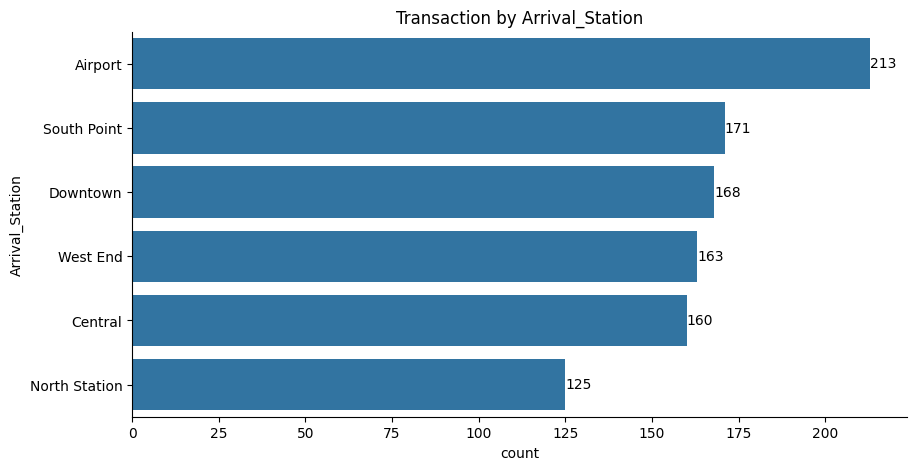

In [40]:
fig, ax =plt.subplots(figsize =(10,5))

ax =sns.countplot(y= data['Arrival_Station'], order = data['Arrival_Station'].value_counts(ascending =False).index)
values =data['Arrival_Station'].value_counts(ascending =True).values
ax.bar_label(container =ax.containers[0], label =values)
plt.title("Transaction by Arrival_Station")
sns.despine()

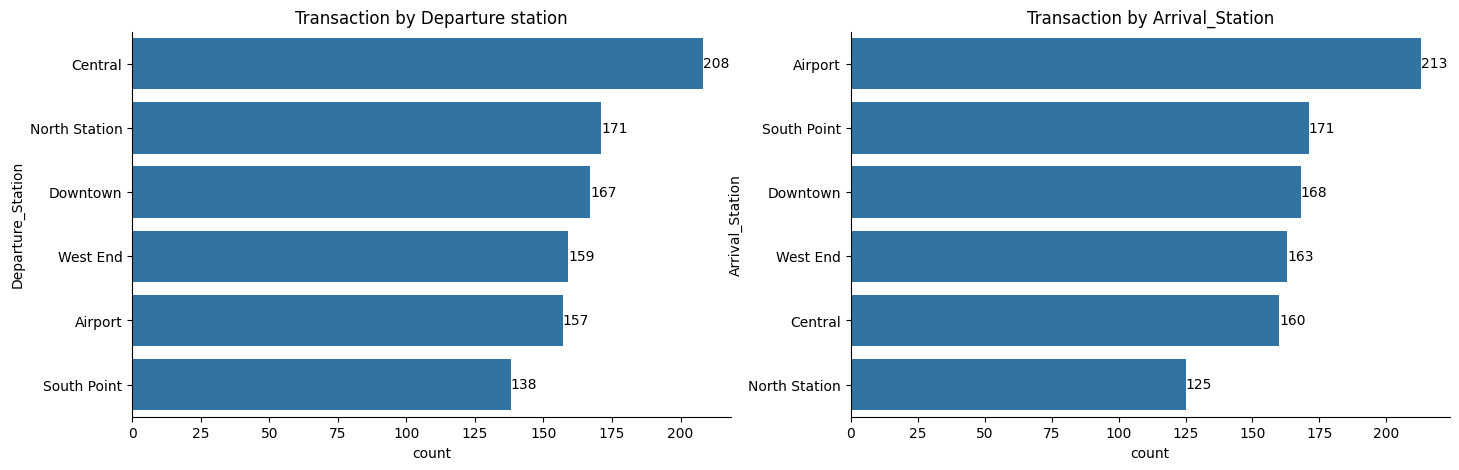

In [41]:
fig, axs =plt.subplots(nrows =1, ncols =2,figsize =(17,5))

ax =sns.countplot(y= data['Departure_Station'], order = data['Departure_Station'].value_counts(ascending =False).index, ax=axs[0])
values =data['Departure_Station'].value_counts(ascending =True).values
ax.bar_label(container =ax.containers[0], label =values)
axs[0].set_title("Transaction by Departure station")
sns.despine()

ax =sns.countplot(y= data['Arrival_Station'], order = data['Arrival_Station'].value_counts(ascending =False).index, ax=axs[1])
values =data['Arrival_Station'].value_counts(ascending =True).values
ax.bar_label(container =ax.containers[0], label =values)
axs[1].set_title("Transaction by Arrival_Station")
sns.despine()

plt.show()

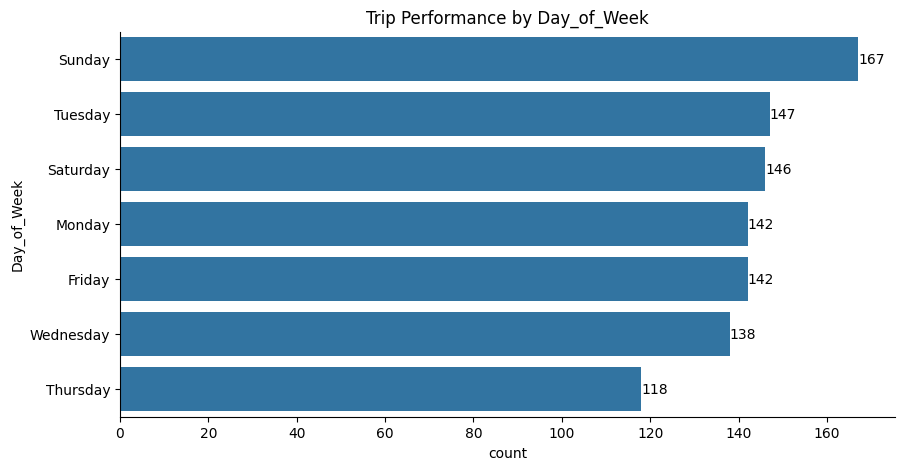

In [42]:
fig, ax =plt.subplots(figsize =(10,5))

ax =sns.countplot(y= data['Day_of_Week'], order = data['Day_of_Week'].value_counts(ascending =False).index)
values =data['Day_of_Week'].value_counts(ascending =True).values
ax.bar_label(container =ax.containers[0], label =values)
plt.title("Trip Performance by Day_of_Week")
sns.despine()

#### Univariate Analysis for Numerical variables

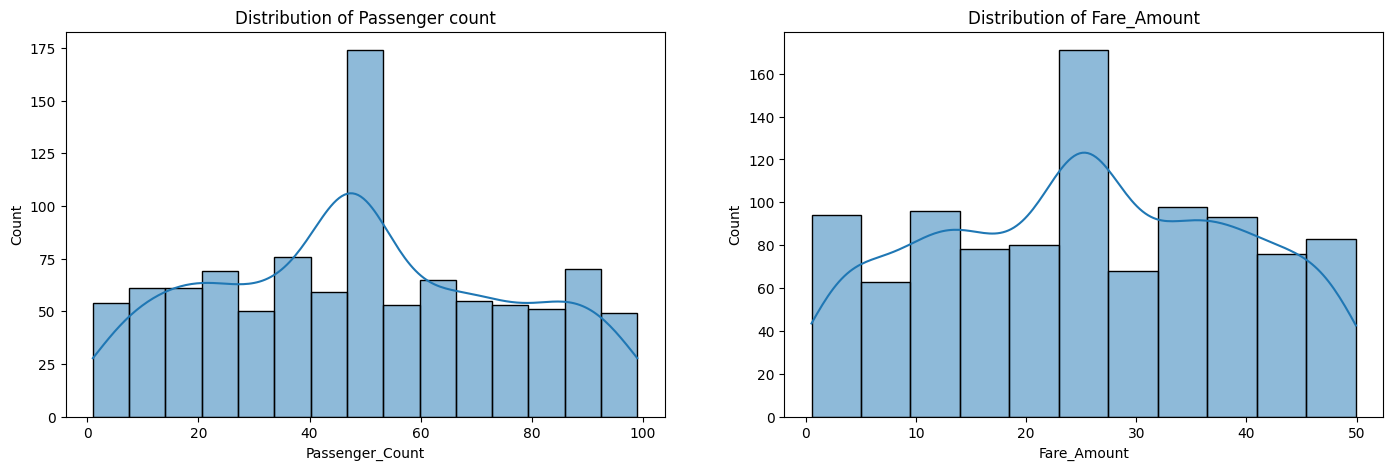

In [43]:
fig, axs =plt.subplots(nrows =1, ncols =2,figsize =(17,5))
sns.histplot(data=data, x = "Passenger_Count", ax=axs[0],  kde=True, bins =15)
axs[0].set_title("Distribution of Passenger count")

sns.histplot(data=data, x = "Fare_Amount", ax=axs[1], kde=True)
axs[1].set_title("Distribution of Fare_Amount");

### Bivariate Analysis

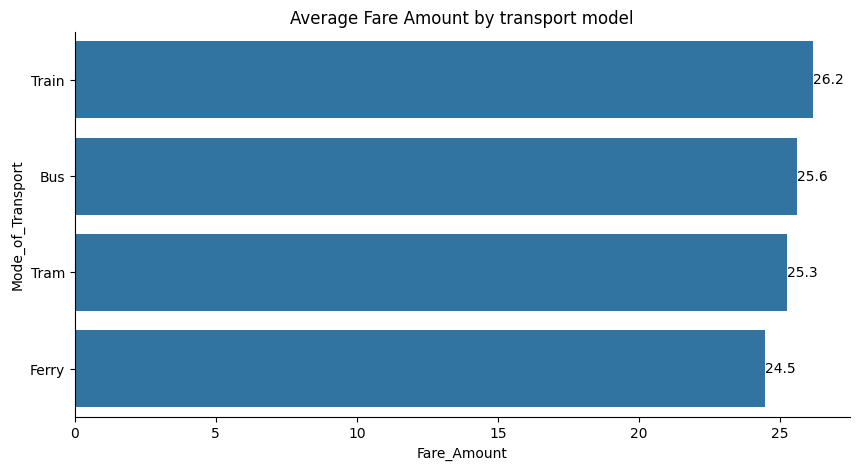

In [44]:
plt.figure(figsize =(10,5))
far =(data.groupby('Mode_of_Transport')['Fare_Amount']
    .mean()
    .reset_index()
    .sort_values(by ='Fare_Amount', ascending =False))
ax =sns.barplot(y='Mode_of_Transport', x ='Fare_Amount', data=far)
ax.set_title("Average Fare Amount by transport model")

for container in ax.containers:
    ax.bar_label(container, fmt ='%.1f')
sns.despine();

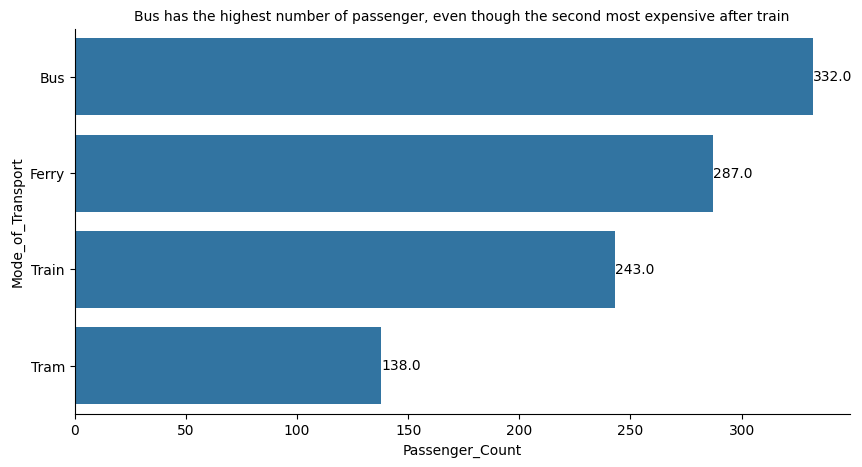

In [45]:
plt.figure(figsize =(10,5))
passenger =(data.groupby('Mode_of_Transport')['Passenger_Count']
    .count()
    .reset_index()
    .sort_values(by ='Passenger_Count', ascending =False))
ax =sns.barplot(y='Mode_of_Transport', x ='Passenger_Count', data=passenger)
ax.set_title("Bus has the highest number of passenger, even though the second most expensive after train", fontsize =10)

for container in ax.containers:
    ax.bar_label(container, fmt ='%.1f')
sns.despine();

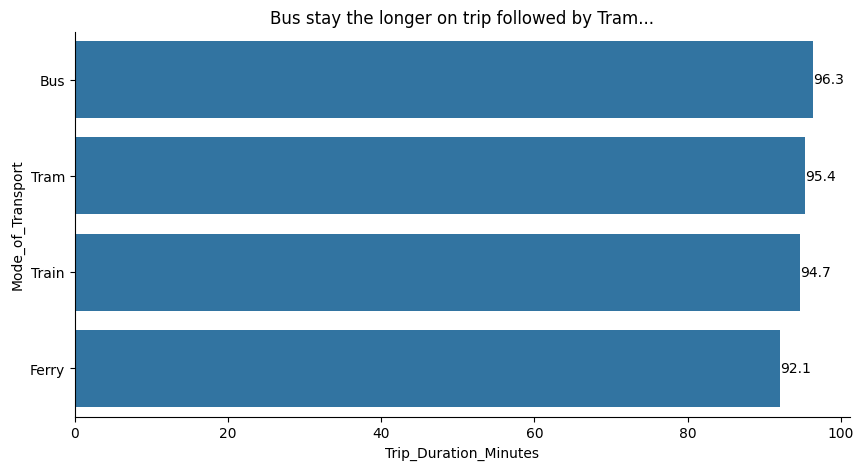

In [46]:
plt.figure(figsize =(10,5))
passenger =(data.groupby('Mode_of_Transport')['Trip_Duration_Minutes']
    .mean()
    .reset_index()
    .sort_values(by ='Trip_Duration_Minutes', ascending =False))
ax =sns.barplot(y='Mode_of_Transport', x ='Trip_Duration_Minutes', data=passenger)
ax.set_title("Bus stay the longer on trip followed by Tram...", fontsize =12)

for container in ax.containers:
    ax.bar_label(container, fmt ='%.1f')
sns.despine();

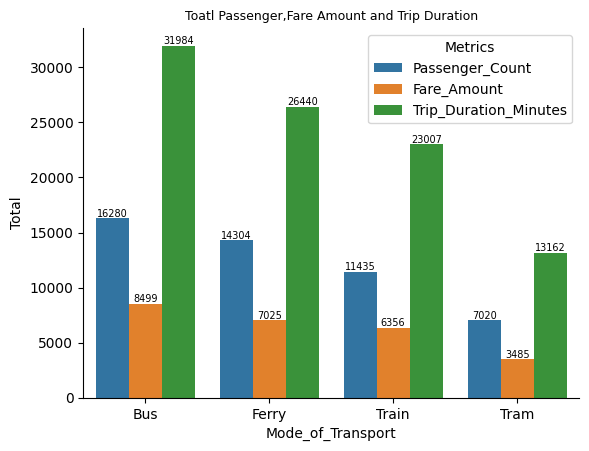

In [47]:
mode =data.groupby('Mode_of_Transport')[['Passenger_Count','Fare_Amount','Trip_Duration_Minutes']].sum().reset_index()
mode1 =pd.melt(mode, id_vars ='Mode_of_Transport', var_name ='Metrics',value_name ='Total')
ax=sns.barplot(data=mode1, x='Mode_of_Transport', y ='Total', hue ='Metrics')
ax.set_title("Toatl Passenger,Fare Amount and Trip Duration", fontsize =9)
for container in ax.containers:
    ax.bar_label(container, fmt ='%.f', fontsize =7)

sns.despine();

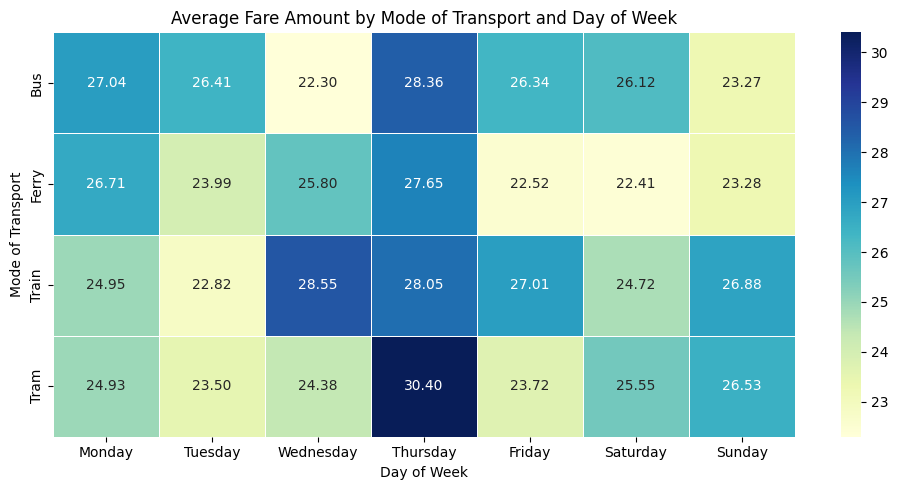

In [48]:
fig, ax=plt.subplots(figsize =(10,5))
fare_heatmap =data.pivot_table(values ='Fare_Amount', columns='Day_of_Week', index ='Mode_of_Transport', aggfunc='mean')
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

fare_heatmap =fare_heatmap.reindex(columns =day_order)

sns.heatmap(fare_heatmap, annot=True,fmt='.2f',cmap='YlGnBu',linewidths=0.5,linecolor='white')

plt.title("Average Fare Amount by Mode of Transport and Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Mode of Transport")

plt.tight_layout()
plt.show()

### Data Validation After Cleaning

In [234]:
data.describe()

,Departure_Time,Passenger_Count,Fare_Amount,Trip_Duration_Minutes,Trip_Date,Hour
count,1000,1000.000000,1000.000000,1000.000000,1000,1000.000000
mean,2024-01-01 14:19:30,49.039000,25.365053,94.593000,2024-01-21 08:03:50.400000,13.840000
min,2024-01-01 06:00:00,1.000000,0.500576,5.000000,2024-01-01 00:00:00,6.000000
25%,2024-01-01 10:09:45,28.000000,13.917364,55.000000,2024-01-11 00:00:00,10.000000
50%,2024-01-01 14:19:30,48.000000,25.403856,97.500000,2024-01-21 00:00:00,14.000000
75%,2024-01-01 18:29:15,70.000000,36.580122,132.250000,2024-02-01 00:00:00,18.000000
max,2024-01-01 22:39:00,99.000000,49.945184,179.000000,2024-02-11 00:00:00,22.000000
std,NaN,26.277709,13.721526,48.043673,NaN,4.816388


In [235]:
data.describe(include ='object')

,Mode_of_Transport,Departure_Station,Arrival_Station,Day_of_Week,Route
count,1000,1000,1000,1000,1000
unique,4,6,6,7,36
top,Bus,Central,Airport,Sunday,North Station → Airport
freq,332,208,213,167,44


In [49]:
data.head()

,Trip_ID,Mode_of_Transport,Departure_Station,Arrival_Station,Departure_Time,Passenger_Count,Fare_Amount,Trip_Duration_Minutes,Trip_Date,Day_of_Week
0,TRIP0001,Ferry,West End,Airport,2024-01-01 06:00:00,21.0,4.343642,26.0,2024-01-01,Sunday
1,TRIP0002,Tram,North Station,Downtown,2024-01-01 06:01:00,46.0,20.673380,134.0,2024-01-01,Saturday
2,TRIP0003,Bus,Central,North Station,2024-01-01 06:02:00,91.0,25.403856,97.5,2024-01-01,Tuesday
3,TRIP0004,Ferry,Downtown,Central,2024-01-01 06:03:00,27.0,3.767487,97.5,2024-01-01,Sunday
4,TRIP0005,Ferry,Downtown,Central,2024-01-01 06:04:00,66.0,25.403856,97.5,2024-01-01,Monday


Trip Performance
Passenger Behaviors
Fare Patterns

In [51]:
print(f"rows: {data.shape[0]}, | columns: {data.shape[1]}")

rows: 1000, | columns: 10


In [59]:
numeric_cols = data.select_dtypes('number').columns
categorical_cols = data.select_dtypes('object').columns

print(f"numeric_cols: {len(numeric_cols)}: {numeric_cols }, categorical_cols: {len(categorical_cols)}:{categorical_cols}")

numeric_cols: 3: Index(['Passenger_Count', 'Fare_Amount', 'Trip_Duration_Minutes'], dtype='object'), categorical_cols: 5:Index(['Trip_ID', 'Mode_of_Transport', 'Departure_Station', 'Arrival_Station',
       'Day_of_Week'],
      dtype='object')


In [76]:
numeric_cols = ['Passenger_Count', 'Fare_Amount', 'Trip_Duration_Minutes']
categorical_cols = ['Mode_of_Transport', 'Departure_Station', 'Arrival_Station', 'Day_of_Week']

In [63]:
duplicates = data[data.duplicated(keep=False)]

if duplicates.empty:
    print("Well done Bro, No Duplicates found")
else:
    print("There is duplicates")

Well done Bro, No Duplicates found


In [77]:
for col in data.columns:
    if col in categorical_cols:
        print("\n", col)
        print(data[col].unique())


 Mode_of_Transport
['Ferry' 'Tram' 'Bus' 'Train']

 Departure_Station
['West End' 'North Station' 'Central' 'Downtown' 'South Point' 'Airport']

 Arrival_Station
['Airport' 'Downtown' 'North Station' 'Central' 'South Point' 'West End']

 Day_of_Week
['Sunday' 'Saturday' 'Tuesday' 'Monday' 'Thursday' 'Wednesday' 'Friday']


In [78]:
data.isnull().sum()

Trip_ID                  0
Mode_of_Transport        0
Departure_Station        0
Arrival_Station          0
Departure_Time           0
Passenger_Count          0
Fare_Amount              0
Trip_Duration_Minutes    0
Trip_Date                0
Day_of_Week              0
dtype: int64

In [83]:
data.groupby("Mode_of_Transport")["Passenger_Count"].apply(lambda x: x.isna().mean()*100)

Mode_of_Transport
Bus      0.0
Ferry    0.0
Train    0.0
Tram     0.0
Name: Passenger_Count, dtype: float64

In [85]:
data.groupby("Mode_of_Transport")["Fare_Amount"].apply(lambda x: x.isna().mean() *100)

Mode_of_Transport
Bus      0.0
Ferry    0.0
Train    0.0
Tram     0.0
Name: Fare_Amount, dtype: float64

In [88]:
data.groupby("Mode_of_Transport")["Departure_Time"].apply(lambda x: x.isna().mean()*100)

Mode_of_Transport
Bus      0.0
Ferry    0.0
Train    0.0
Tram     0.0
Name: Departure_Time, dtype: float64

In [ ]:
# #Filling trip duration missing values with Group-based median imputation

# df['Trip_Duration_Minutes'] = df.groupby(
#     ['Mode_of_Transport', 'Day_of_Week']
# )['Trip_Duration_Minutes'].transform(lambda x: x.fillna(x.median()))

In [89]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Trip_ID                1000 non-null   object        
 1   Mode_of_Transport      1000 non-null   object        
 2   Departure_Station      1000 non-null   object        
 3   Arrival_Station        1000 non-null   object        
 4   Departure_Time         1000 non-null   datetime64[ns]
 5   Passenger_Count        1000 non-null   float64       
 6   Fare_Amount            1000 non-null   float64       
 7   Trip_Duration_Minutes  1000 non-null   float64       
 8   Trip_Date              1000 non-null   datetime64[ns]
 9   Day_of_Week            1000 non-null   object        
dtypes: datetime64[ns](2), float64(3), object(5)
memory usage: 78.3+ KB


In [90]:
data['Hour'] = data['Departure_Time'].dt.hour
data.head(2)

,Trip_ID,Mode_of_Transport,Departure_Station,Arrival_Station,Departure_Time,Passenger_Count,Fare_Amount,Trip_Duration_Minutes,Trip_Date,Day_of_Week,Hour
0,TRIP0001,Ferry,West End,Airport,2024-01-01 06:00:00,21.0,4.343642,26.0,2024-01-01,Sunday,6
1,TRIP0002,Tram,North Station,Downtown,2024-01-01 06:01:00,46.0,20.673380,134.0,2024-01-01,Saturday,6


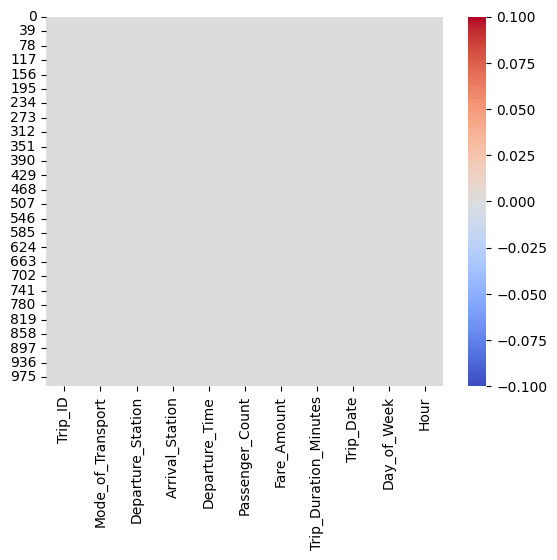

In [93]:
sns.heatmap(data.isnull(), cmap ='coolwarm')
plt.show()

In [94]:
data.isnull().sum()

Trip_ID                  0
Mode_of_Transport        0
Departure_Station        0
Arrival_Station          0
Departure_Time           0
Passenger_Count          0
Fare_Amount              0
Trip_Duration_Minutes    0
Trip_Date                0
Day_of_Week              0
Hour                     0
dtype: int64

In [95]:
data.columns

Index(['Trip_ID', 'Mode_of_Transport', 'Departure_Station', 'Arrival_Station',
       'Departure_Time', 'Passenger_Count', 'Fare_Amount',
       'Trip_Duration_Minutes', 'Trip_Date', 'Day_of_Week', 'Hour'],
      dtype='object')

In [96]:
data.drop('Trip_ID', axis = 1, inplace =True)
data.columns

Index(['Mode_of_Transport', 'Departure_Station', 'Arrival_Station',
       'Departure_Time', 'Passenger_Count', 'Fare_Amount',
       'Trip_Duration_Minutes', 'Trip_Date', 'Day_of_Week', 'Hour'],
      dtype='object')

In [97]:
numeric_cols = data.select_dtypes('number').columns
categorical_cols = data.select_dtypes('object').columns

print(f"numeric_cols: {len(numeric_cols)}: {numeric_cols }, categorical_cols: {len(categorical_cols)}:{categorical_cols}")

numeric_cols: 4: Index(['Passenger_Count', 'Fare_Amount', 'Trip_Duration_Minutes', 'Hour'], dtype='object'), categorical_cols: 4:Index(['Mode_of_Transport', 'Departure_Station', 'Arrival_Station',
       'Day_of_Week'],
      dtype='object')


In [98]:
numerical_cols = ['Passenger_Count', 'Fare_Amount', 'Trip_Duration_Minutes', 'Hour']
categorical_cols = ['Mode_of_Transport', 'Departure_Station', 'Arrival_Station','Day_of_Week']

### Data Visualization/Analysis

### Univariate Analysis
Q1: Trip Volume over time

Q2: Volume of trips by Day_of_Week over time

Q3: What is the distribution of Model of transport, Departure Station and Arrival Station

Q4: What is the distribution of Passenger, Fare Amount and Trip Duration

### Bivariate Analysis

Q5: Operations metrics over time(Trip demand, passenger demand and revenue analysis)

Q6: Which Model of transport has the large number of customers?

Q7: Look at the model of transportation by Fare Amount

Q8: Total Trips by Days of the week

Q9: Which Departure Station has the most trips?

Q10: Model of transport by Average Fare Amount

Q11: Relationship between Fare_Amount and Trip_Duration_Minutes

Q12: Trip Performance: Average Trip, Passenger demand Fare Variation by Hour of the Day

### Multivariate Analysis

Q16: Which Stations got the highest Revenue Per pessenger?

Q17: Hour of day vs Model of transport

Q18: Trip Duration by Route taken and model of transportation

In [99]:
data.head(2)

,Mode_of_Transport,Departure_Station,Arrival_Station,Departure_Time,Passenger_Count,Fare_Amount,Trip_Duration_Minutes,Trip_Date,Day_of_Week,Hour
0,Ferry,West End,Airport,2024-01-01 06:00:00,21.0,4.343642,26.0,2024-01-01,Sunday,6
1,Tram,North Station,Downtown,2024-01-01 06:01:00,46.0,20.673380,134.0,2024-01-01,Saturday,6


#### Q1: Volume of trips by model of transport over time

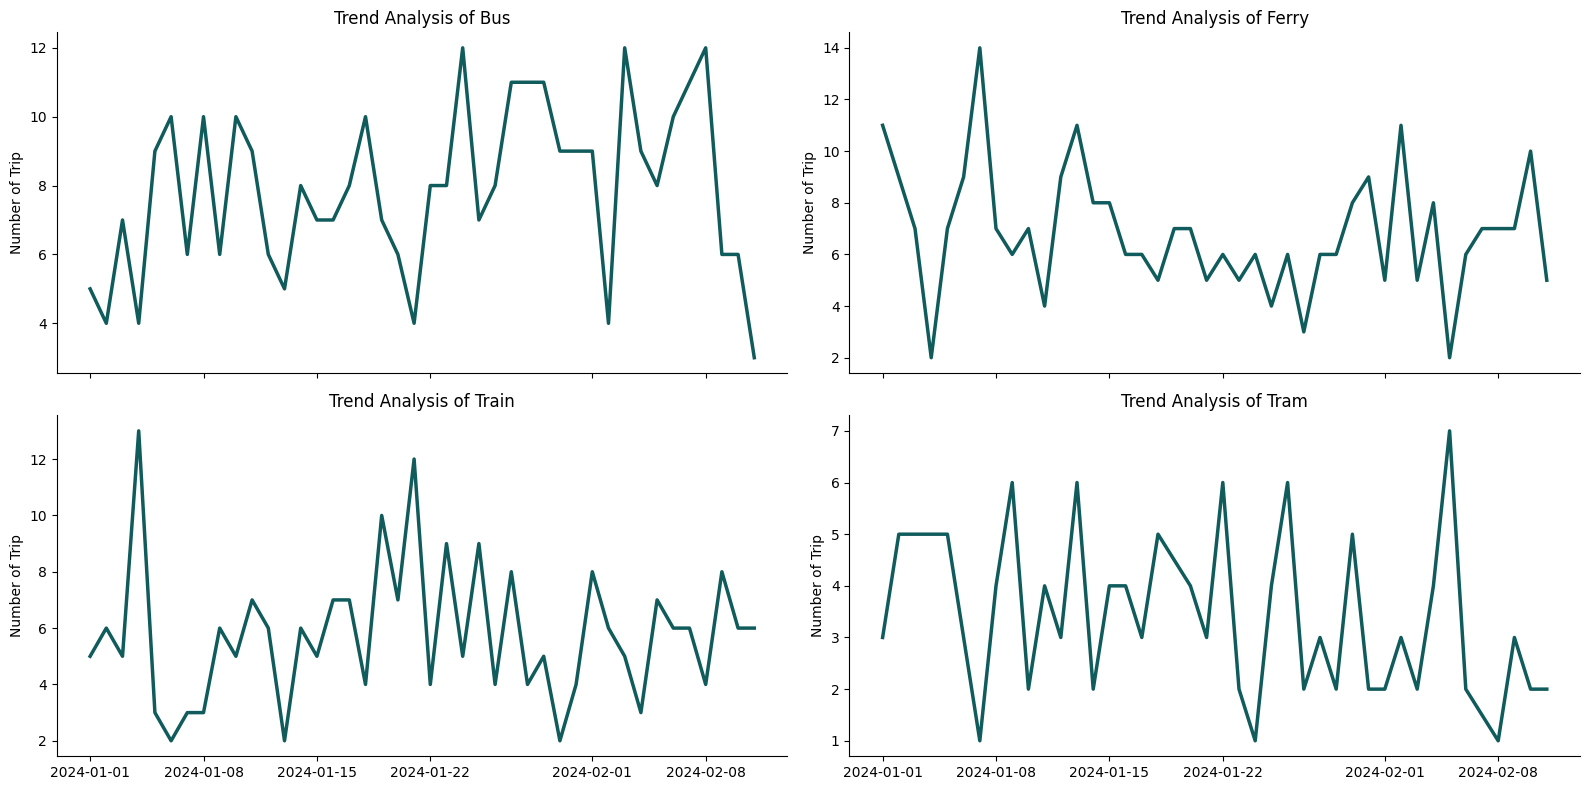

In [236]:
colors = ['#105b5c','#e8eeed']
models =data['Mode_of_Transport'].value_counts().index[:4]

fig, axes =plt.subplots(2, 2, figsize =(16, 8), sharex =True)
axes=axes.flatten()

for i, model in enumerate(models):
    models_data = data[data['Mode_of_Transport'] ==model]

    trend_data =models_data.groupby('Trip_Date')['Mode_of_Transport'].count()

    axes[i].plot(trend_data.index, trend_data.values, color ='#105b5c', linewidth =2.5)
    axes[i].set_title(f'Trend Analysis of {model}')
    axes[i].set_ylabel('Number of Trip')

sns.despine()
plt.tight_layout()
plt.savefig(r"C:\Users\hp\Desktop\90_Day_Project\Day 16\Transport Analysis\C_1.png",dpi=300, bbox_inches="tight")
plt.show()


**Insight**: There are patterns of  consistent fluctuation in the various model of transport. The daily patterns varies across time

#### Q2: Volume of trips by Day_of_Week over time

**Insights** Days of the weeks depicts a pattern of weekly trend over daily trips. The fluctuation varies by time of the fay

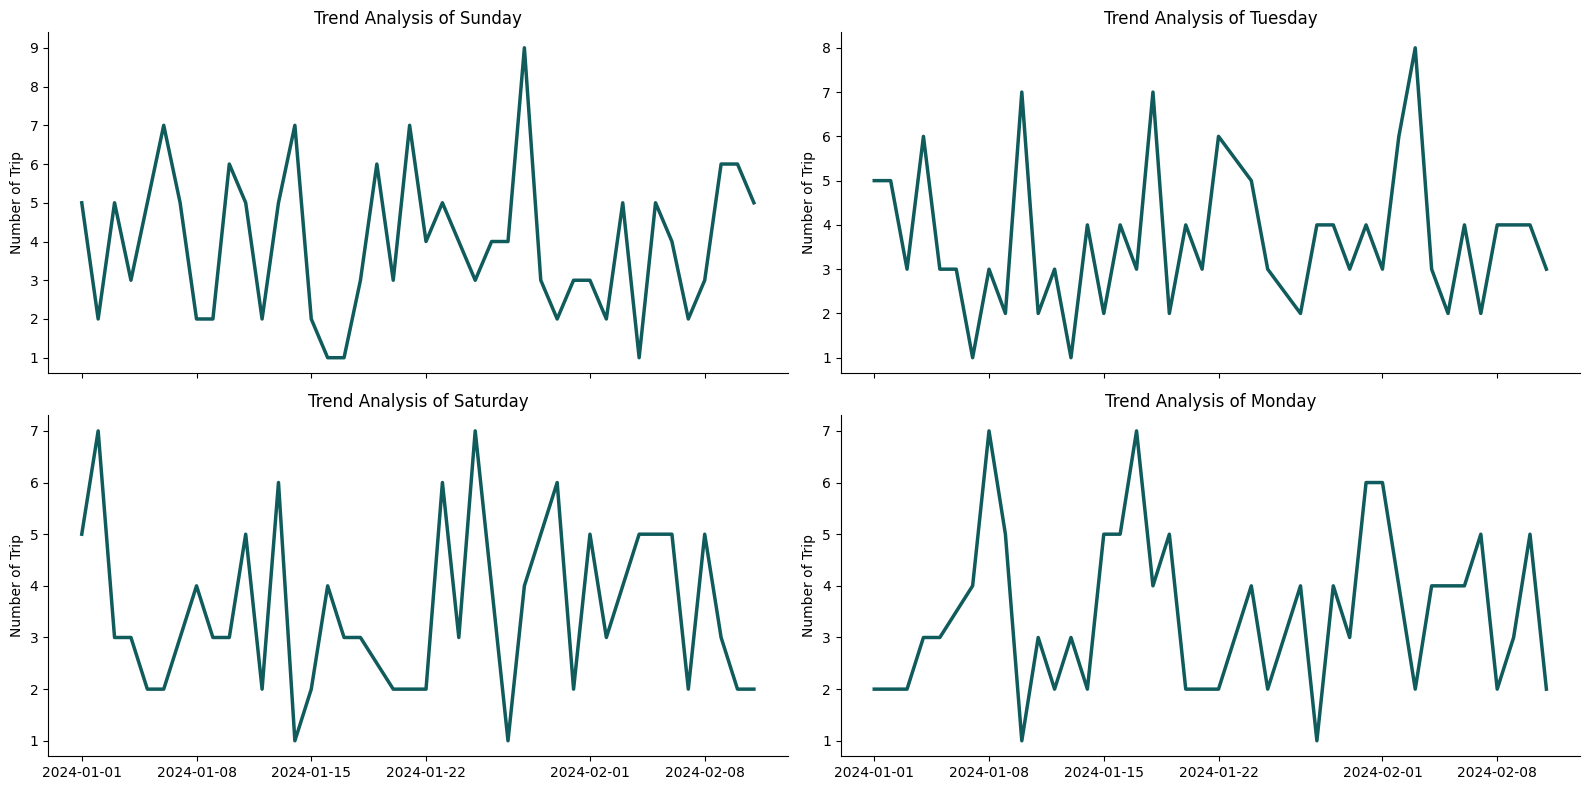

In [237]:
weeks =data['Day_of_Week'].value_counts().index[:4]

fig, axes =plt.subplots(2, 2, figsize =(16, 8), sharex =True)
axes=axes.flatten()

for i, week in enumerate(weeks):
    weekly_data = data[data['Day_of_Week'] ==week]

    weekly_trend_data =weekly_data.groupby('Trip_Date')['Day_of_Week'].count()

    axes[i].plot(weekly_trend_data.index, weekly_trend_data.values, color ='#105b5c', linewidth =2.5)
    axes[i].set_title(f'Trend Analysis of {week}')
    axes[i].set_ylabel('Number of Trip')

sns.despine()
plt.tight_layout()
plt.savefig(r"C:\Users\hp\Desktop\90_Day_Project\Day 16\Transport Analysis\C_2.png",dpi=300, bbox_inches="tight")
plt.show()

**Insight**: There are patterns of  consistent fluctuation in the various days of the week trips. The daily patterns varies across time of the week

In [ ]:
Q3: What is the distribution of Model of transport, Departure Station and Arrival Station
Q4: What is the distribution of Passenger, Fare Amount and Trip Duration

#### Q3: What is the distribution of Model of transport, Departure Station and Arrival Station
Which Model of transport has the large number of customers?

Which Departure Station has the most trips?

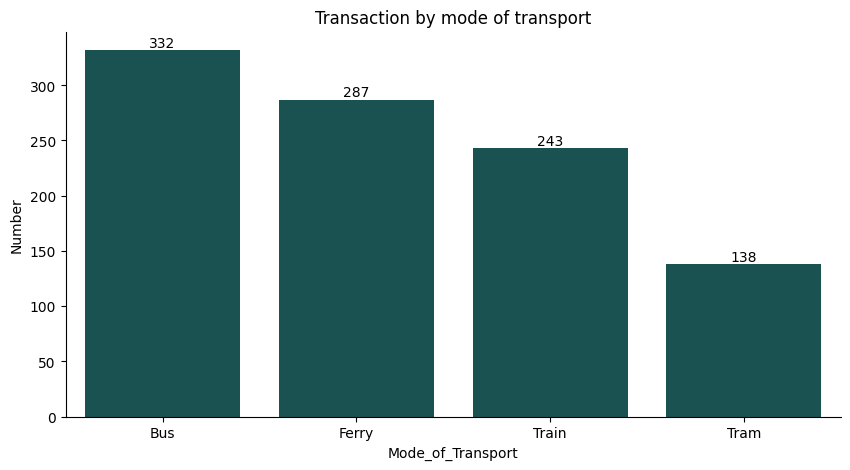

In [238]:
fig, ax =plt.subplots(figsize =(10, 5))

ax =sns.countplot(x =data['Mode_of_Transport'], order =data['Mode_of_Transport'].value_counts(ascending =False).index, color ='#105b5c')
values =data['Mode_of_Transport'].value_counts(ascending =False).values
ax.bar_label(container =ax.containers[0], label =values)
plt.title("Transaction by mode of transport")
plt.ylabel("Number")
sns.despine()
plt.savefig(r"C:\Users\hp\Desktop\90_Day_Project\Day 16\Transport Analysis\C_3.png",dpi=300, bbox_inches="tight");

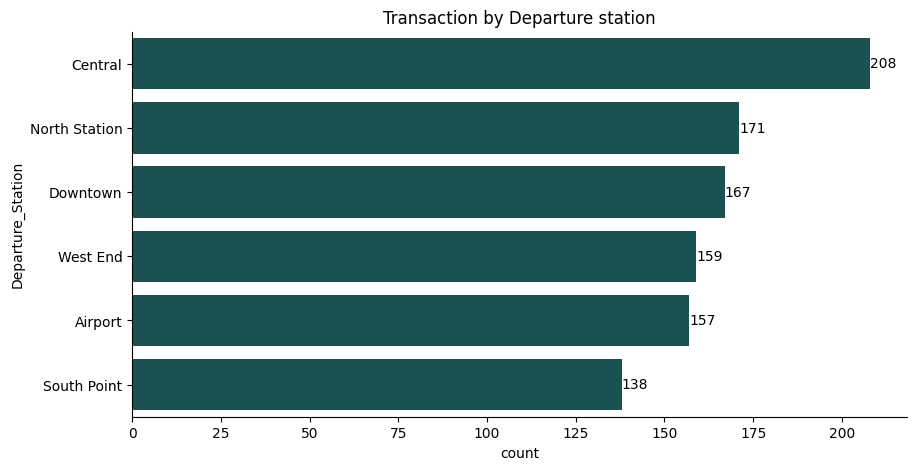

In [239]:
fig, ax =plt.subplots(figsize =(10,5))

ax =sns.countplot(y= data['Departure_Station'], order = data['Departure_Station'].value_counts(ascending =False).index,  color ='#105b5c')
values =data['Departure_Station'].value_counts(ascending =True).values
ax.bar_label(container =ax.containers[0], label =values)
plt.title("Transaction by Departure station")
sns.despine()
plt.savefig(r"C:\Users\hp\Desktop\90_Day_Project\Day 16\Transport Analysis\C_4.png",dpi=300, bbox_inches="tight")

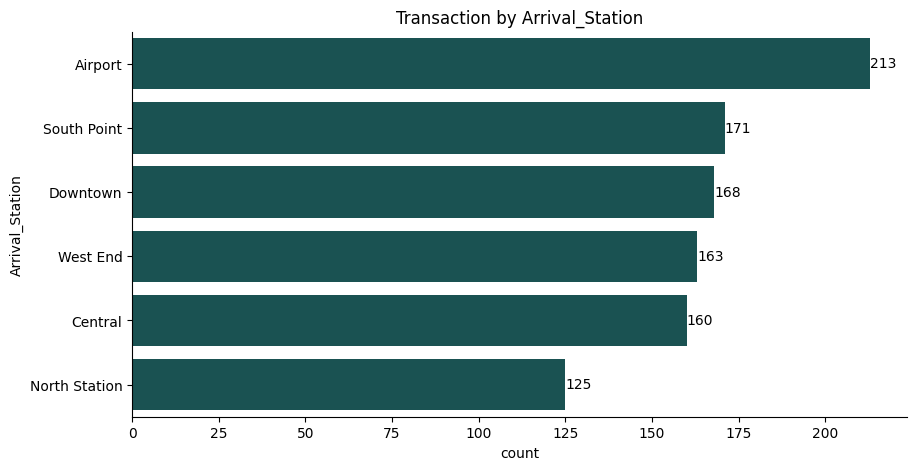

In [240]:
fig, ax =plt.subplots(figsize =(10,5))

ax =sns.countplot(y= data['Arrival_Station'], order = data['Arrival_Station'].value_counts(ascending =False).index, color ='#105b5c')
values =data['Arrival_Station'].value_counts(ascending =True).values
ax.bar_label(container =ax.containers[0], label =values)
plt.title("Transaction by Arrival_Station")
sns.despine()
plt.savefig(r"C:\Users\hp\Desktop\90_Day_Project\Day 16\Transport Analysis\C_5.png",dpi=300, bbox_inches="tight")

**Insight**

Bus top the list in the mode of transportm follwed by Ferry(this mode of transportation is very suitable for short trips/journey)

The top performing departure stations are Central, North and the Downtown station. These stations marked the top 3 performing station with the largest number of customers. The 3 bottom performing stations are South Point, Airpot and West End, while West End and Airport are too far each - difference of 2 points South Point seems to be the worse performing station with 20 and 18 points difference respectively from West End and Airport.

From the charts above, we can infer that even though South Point, Airport,and West End recorded the worst departure stations. They top the list as the first 2 performing arrival stations aside the West End that appear the fourth on the list.

#### Q4: What is the distribution of Passenger, Fare Amount and Trip Duration

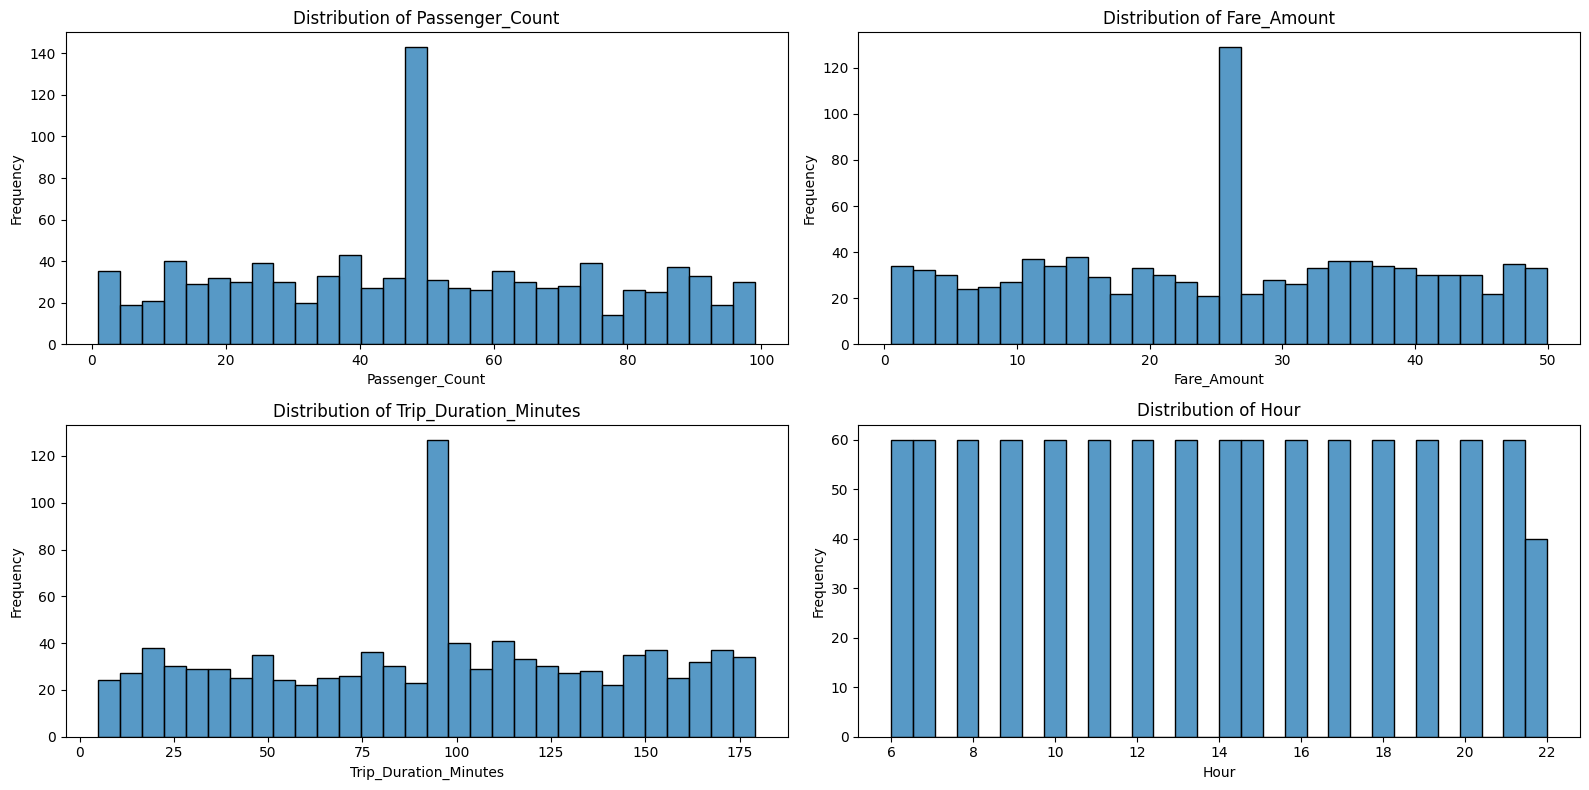

In [159]:
numerical_cols = ['Passenger_Count', 'Fare_Amount', 'Trip_Duration_Minutes', 'Hour']

fig, axes =plt.subplots(2, 2, figsize =(16, 8))
axes=axes.flatten()
for i, col in enumerate(numerical_cols):
    sns.histplot(data, x =col, bins =30, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

The distribution of Passenger, Fare Amount and Trip Duration shows nearly uniform distribution. Hour of the day is more like a discrete number not continous like other that is why it is looking like that

### Bivariate Analysis
**Q5:** Operations metrics over time(Trip demand, passenger demand and revenue analysis)

**Q6:** Look at the model of transportation by Fare Amount

**Q7:** Total Trips by Days of the week

**Q8:** Relationship between Fare_Amount and Trip_Duration_Minutes

**Q9:** Average Trip by Hour of the Day, Hour of day most travel occured, Fare Variation by Hour of the day

#### Q5: Demamd/Operations Analysis over time(Trip demand, passenger demand and revenue analysis)

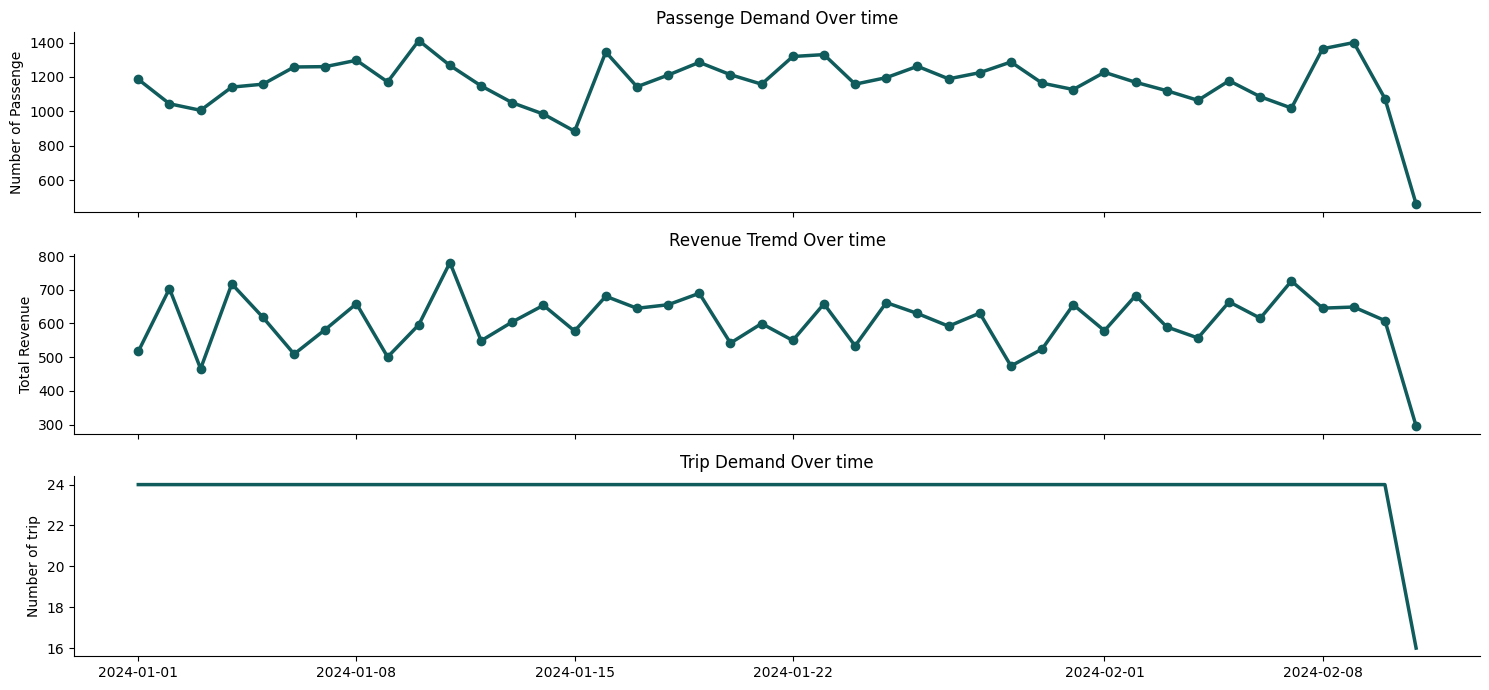

In [241]:
Trip_demands =data.groupby('Trip_Date')['Trip_Date'].count()
passenge_demand = data.groupby('Trip_Date')['Passenger_Count'].sum()
revenue = data.groupby('Trip_Date')['Fare_Amount'].sum()

fig, axes =plt.subplots(3,1, figsize =(15, 7), sharex =True)

axes[0].plot(passenge_demand.index, passenge_demand.values, linewidth =2.5, marker ='o',  color ='#105b5c')
axes[0].set_title("Passenge Demand Over time")
axes[0].set_ylabel("Number of Passenge")
sns.despine()

axes[1].plot(revenue.index, revenue.values, linewidth =2.5, marker ='o',  color ='#105b5c')
axes[1].set_title("Revenue Tremd Over time")
axes[1].set_ylabel("Total Revenue")
sns.despine()

axes[2].plot(Trip_demands.index, Trip_demands.values, linewidth =2.5,  color ='#105b5c')
axes[2].set_title("Trip Demand Over time")
axes[2].set_ylabel("Number of trip")
sns.despine()


plt.tight_layout()
plt.savefig(r"C:\Users\hp\Desktop\90_Day_Project\Day 16\Transport Analysis\C_6.png",dpi=300, bbox_inches="tight")
plt.show()


**Insight** 

There have ups and downs in the number of passenge demand and Revenue over time with the demand and revenue pick around 1st  and 15th of Jan and and consistent decline arouns Feb. While the trip patterns remains constant or consistent over time except during this decline period 9 (as experienced in the demand and revenue behaviour

#### Q6: Look at the model of transportation by Average Fare Amount

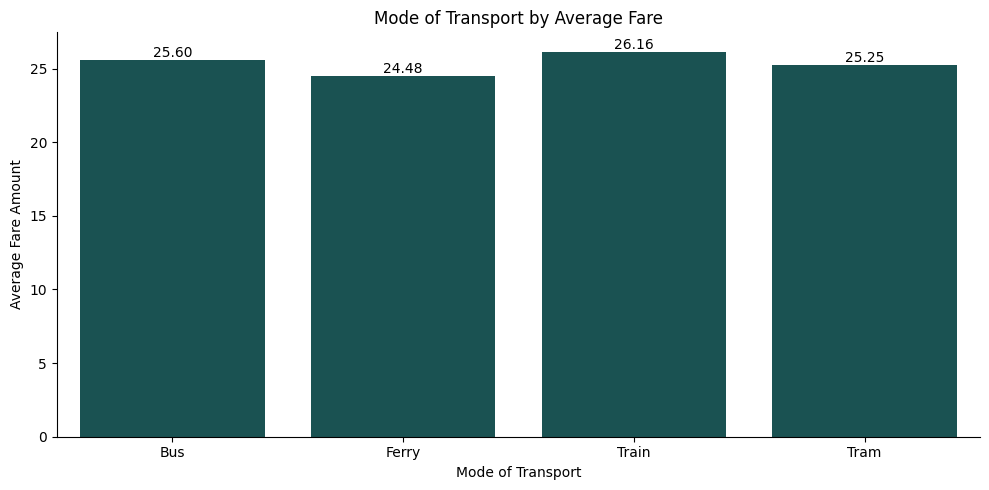

In [242]:
avg_data = data.groupby('Mode_of_Transport')['Fare_Amount'].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(
    data=avg_data,
    x='Mode_of_Transport',
    y='Fare_Amount',
    ax=ax,
    color ='#105b5c'
)

# Add labels on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

ax.set_title("Mode of Transport by Average Fare")
ax.set_ylabel("Average Fare Amount")
ax.set_xlabel("Mode of Transport")

sns.despine()
plt.tight_layout()
plt.savefig(r"C:\Users\hp\Desktop\90_Day_Project\Day 16\Transport Analysis\C_7.png",dpi=300, bbox_inches="tight")
plt.show()

**Insight**

Train is the most expensive Model of transport with an average fare of 26.16 USD followed by Bus (25.60 USD), While Ferry (24.48 USD) is the cheapest model of Transportation

#### Q7: Total Trips by Days of the week

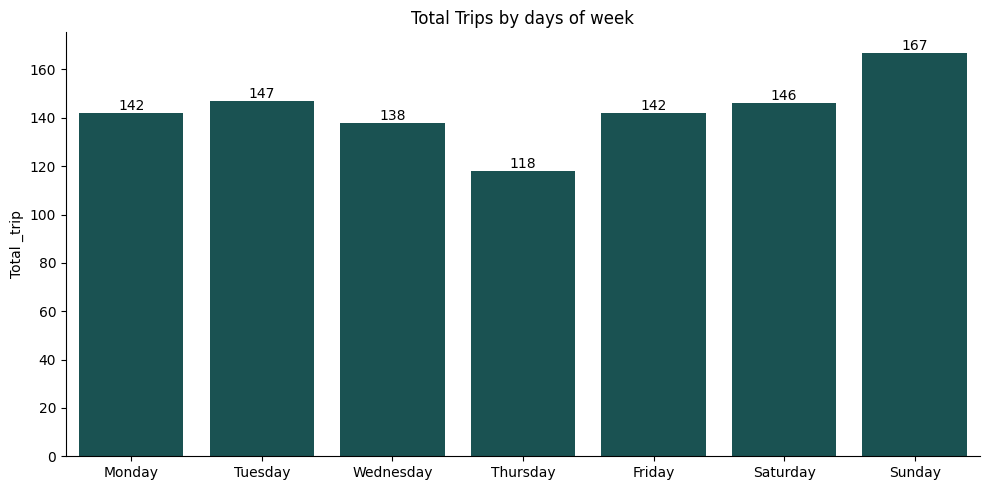

In [243]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
total =data.groupby('Day_of_Week')['Trip_Date'].count().reindex(day_order).reset_index()

fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(
    data=total,
    x='Day_of_Week',
    y='Trip_Date',
    ax=ax,
    color ='#105b5c'
)

# Add labels on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')

ax.set_title("Total Trips by days of week")
ax.set_ylabel("Total _trip")
ax.set_xlabel("")

sns.despine()
plt.tight_layout()
plt.savefig(r"C:\Users\hp\Desktop\90_Day_Project\Day 16\Transport Analysis\C_8.png",dpi=300, bbox_inches="tight")
plt.show()

**Insight**

Sunday depicts the most day of the week by total trip (over 167 trip) per sunday followed by Tuesday(147) and the lowest day is Thursday (118)

#### Q8: Relationship between Fare_Amount and Trip_Duration_Minutes

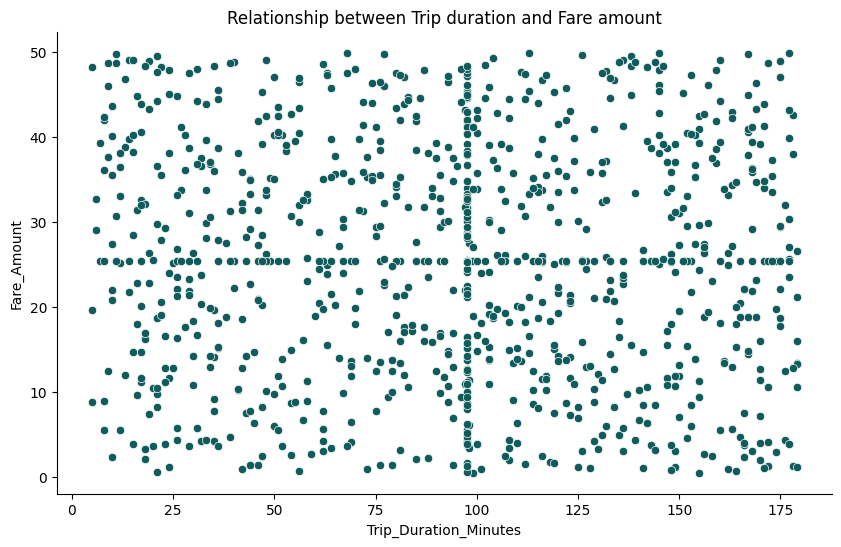

In [244]:
plt.figure(figsize =(10, 6))
sns.scatterplot(data, x = 'Trip_Duration_Minutes', y= 'Fare_Amount',  color ='#105b5c')
plt.title("Relationship between Trip duration and Fare amount")
sns.despine()
plt.savefig(r"C:\Users\hp\Desktop\90_Day_Project\Day 16\Transport Analysis\C_9.png",dpi=300, bbox_inches="tight")
plt.show()

We can't pick any strong relationship between trip duration and fare amount. I was thinking longer trip duration will cost higher fare amount 

#### Trip Performance: Average Trip, Passenger demand Fare Variation by Hour of the Day

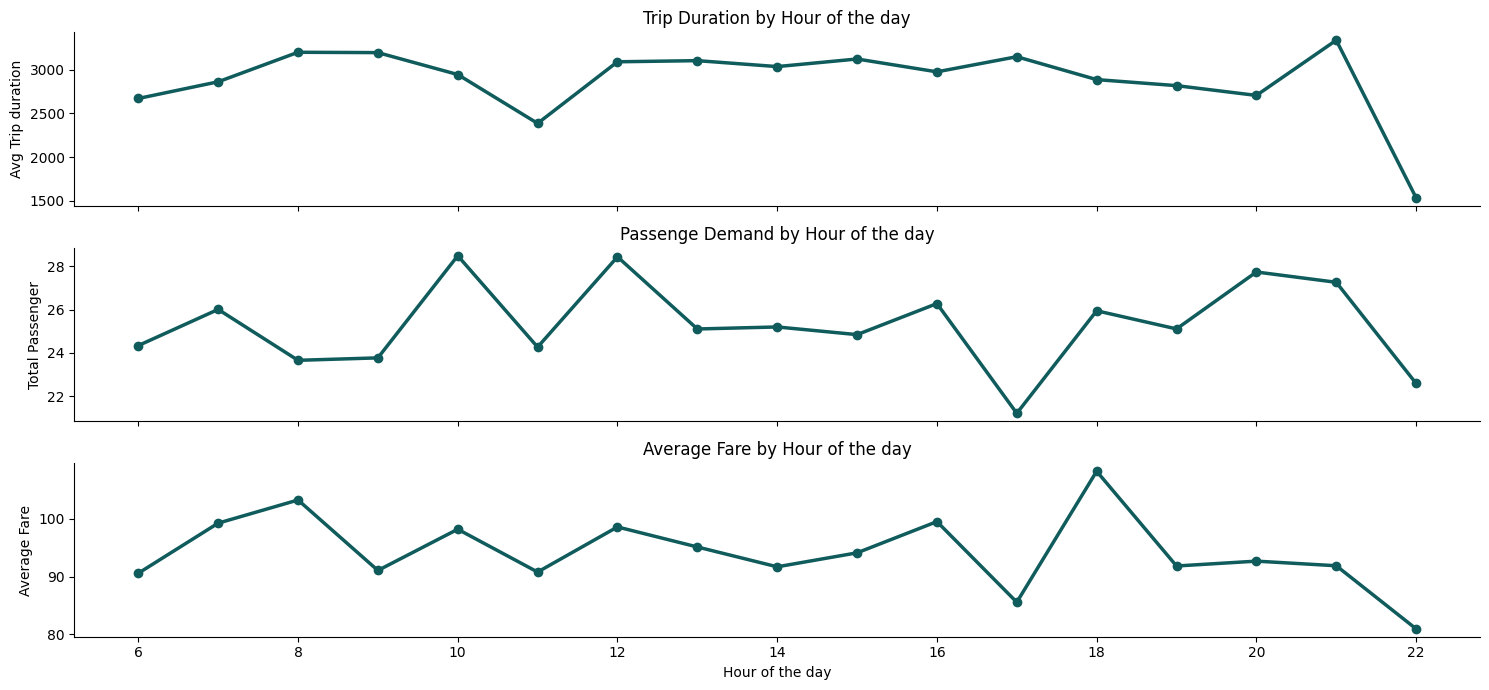

In [245]:
Trip_demands =data.groupby('Hour')['Trip_Duration_Minutes'].mean()
passenge_demand = data.groupby('Hour')['Passenger_Count'].sum()
revenue = data.groupby('Hour')['Fare_Amount'].mean()

fig, axes =plt.subplots(3,1, figsize =(15, 7), sharex =True)

axes[0].plot(passenge_demand.index, passenge_demand.values, linewidth =2.5, marker ='o',  color ='#105b5c')
axes[0].set_title("Trip Duration by Hour of the day")
axes[0].set_ylabel("Avg Trip duration")
sns.despine()

axes[1].plot(revenue.index, revenue.values,linewidth =2.5, marker ='o',  color ='#105b5c')
axes[1].set_title("Passenge Demand by Hour of the day")
axes[1].set_ylabel("Total Passenger")
sns.despine()

axes[2].plot(Trip_demands.index, Trip_demands.values, linewidth =2.5, marker ='o',  color ='#105b5c')
axes[2].set_title("Average Fare by Hour of the day")
axes[2].set_ylabel("Average Fare")
sns.despine()

plt.xlabel("Hour of the day")
plt.tight_layout()
plt.savefig(r"C:\Users\hp\Desktop\90_Day_Project\Day 16\Transport Analysis\C_10.png",dpi=300, bbox_inches="tight")
plt.show()


**Insights:**

1. **Average trip duration is highest at 8 AM and 6 PM**, which aligns with typical morning and evening commute periods. The shortest trips occur late at night, from around **10 PM onward**, suggesting that peak hours are dominated by longer and busier routes, while late-night trips are generally quicker and lighter.

2. **Passenger demand peaks at 8 AM and again at 9 PM**, showing two clear periods of high travel activity. Demand dips noticeably around **11 AM** and drops sharply after **10 PM**, indicating reduced travel movement during late-night hours.

3. Overall, the data suggests two major travel surges: a **morning commute rush** and a **late-evening demand peak**, with relatively stable but lower activity during midday and a strong decline late at night.


### Multivariate Analysis

Q16: Which Stations got the highest Revenue Per pessenger?

Q17: Hour of day vs Model of transport

Q18: Trip Duration by Route taken and model of transportation

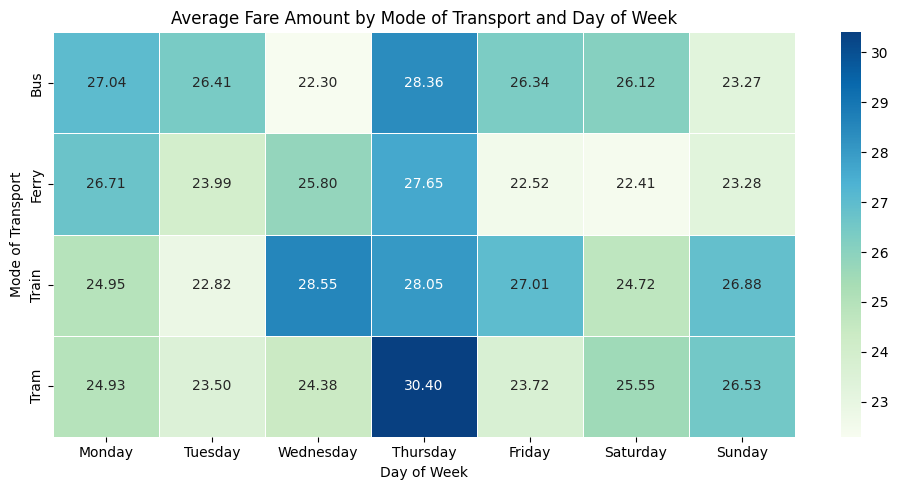

In [246]:
fig, ax=plt.subplots(figsize =(10,5))
fare_heatmap =data.pivot_table(values ='Fare_Amount', columns='Day_of_Week', index ='Mode_of_Transport', aggfunc='mean')
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

fare_heatmap =fare_heatmap.reindex(columns =day_order)

sns.heatmap(fare_heatmap, annot=True,fmt='.2f',cmap='GnBu',linewidths=0.5,linecolor='white')

plt.title("Average Fare Amount by Mode of Transport and Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Mode of Transport")

plt.tight_layout()
plt.savefig(r"C:\Users\hp\Desktop\90_Day_Project\Day 16\Transport Analysis\C_11.png",dpi=300, bbox_inches="tight")
plt.show()

**Insights**

From the analysis, the average fare varies by mode of transport and day of the week. Tram records its highest average fare on Thursday, at 30.40 per trip, while Train is most expensive on Wednesday, with an average fare of 28.55 per trip. Ferry also reaches its highest average fare on Thursday, with an average fare of 26.65 per trip and Bus with highest average fare of 28.36 on Thursday.

#### Q16: Which Stations got the highest Revenue Per pessenger?

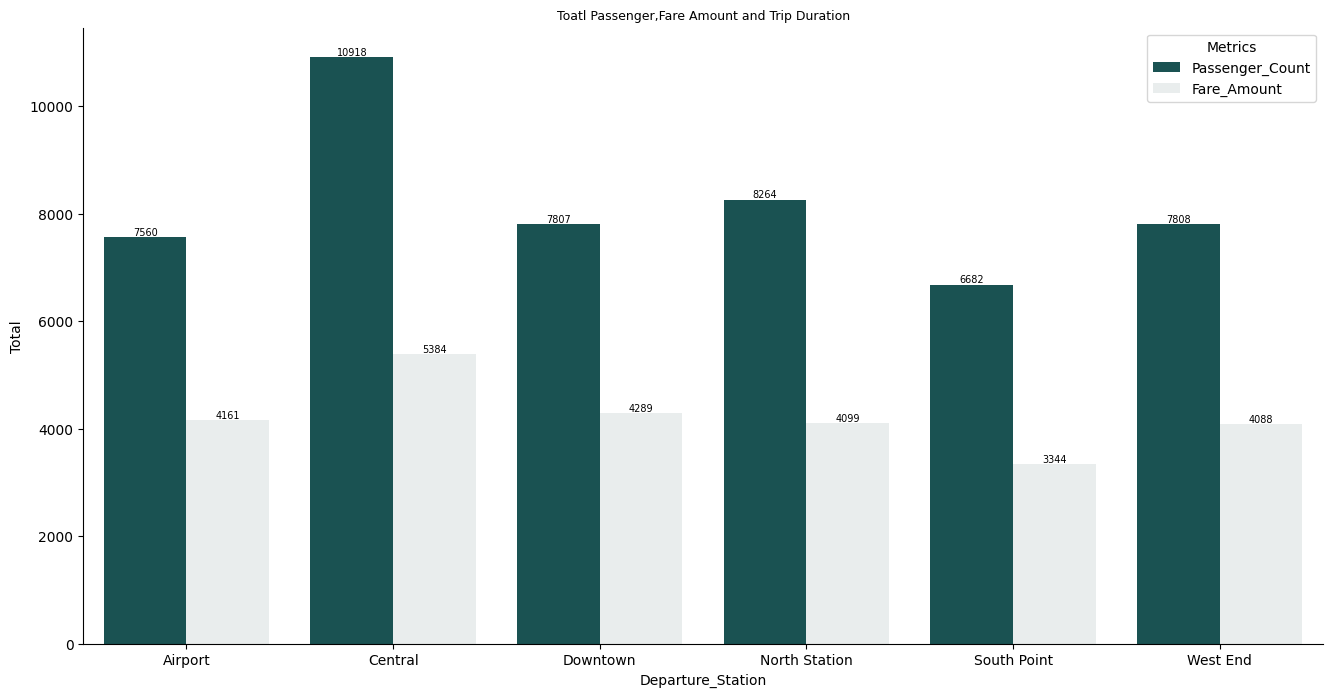

In [247]:
fig, ax =plt.subplots(figsize =(16,8))
mode =data.groupby('Departure_Station').agg({'Passenger_Count':'sum','Fare_Amount':'sum'}).reset_index()
mode1 =pd.melt(mode, id_vars ='Departure_Station', var_name ='Metrics',value_name ='Total')
ax=sns.barplot(data=mode1, x='Departure_Station', y ='Total', hue ='Metrics', palette=colors)
ax.set_title("Toatl Passenger,Fare Amount and Trip Duration", fontsize =9)
for container in ax.containers:
    ax.bar_label(container, fmt ='%.f', fontsize =7)

sns.despine()
plt.savefig(r"C:\Users\hp\Desktop\90_Day_Project\Day 16\Transport Analysis\C_12.png",dpi=300, bbox_inches="tight");

Central Station records the highest passenger volume and generates the most fare revenue, making it the busiest and most profitable station. In contrast, South Point shows the lowest activity across both passenger count and fare revenue.


#### Q17: Hour of day vs Model of transport

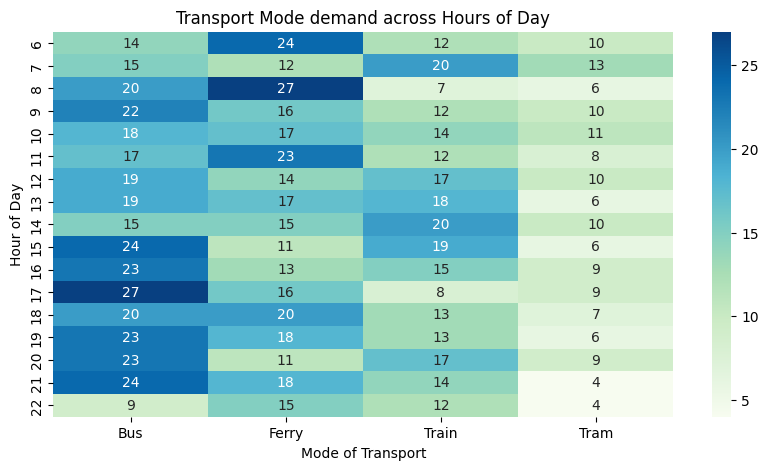

In [250]:
 # Creating a table for Transport Mode Vs Clock Hour
model_time = pd.crosstab(data['Hour'], data['Mode_of_Transport'])

 # Visualization
fig, ax=plt.subplots(figsize =(10,5))
sns.heatmap(model_time, cmap='GnBu', annot=True, fmt='d')
plt.title('Transport Mode demand across Hours of Day')
plt.xlabel('Mode of Transport')
plt.ylabel('Hour of Day')

plt.savefig(r"C:\Users\hp\Desktop\90_Day_Project\Day 16\Transport Analysis\C_13.png",dpi=300, bbox_inches="tight")
plt.show()

Demand is strongly shaped by transport mode and time of day. Buses dominate afternoon and evening travel, ferries peak in the morning, trains show two smaller spikes around 7 AM and 2 PM, while trams remain consistently underutilized across the day.

#### Q18: Trip Duration by Route taken and model of transportation

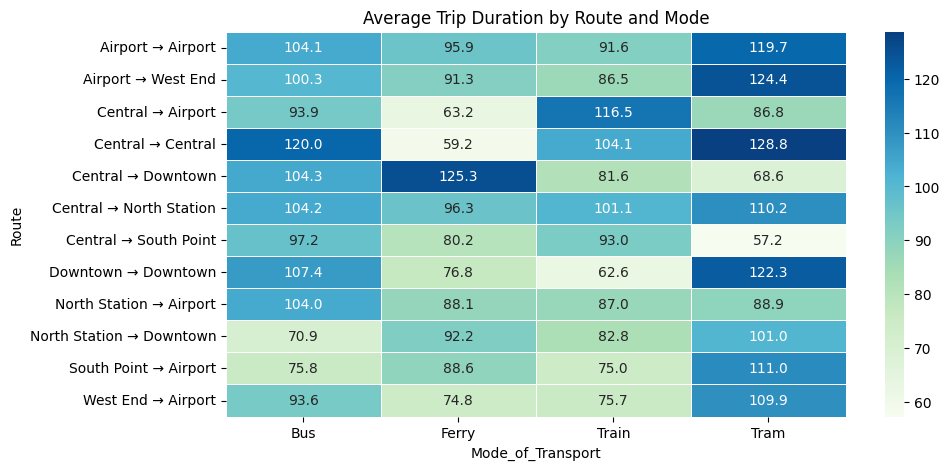

In [251]:
 #Creating route feature
data['Route'] = data['Departure_Station'] + " → " + data['Arrival_Station']
route_counts = data['Route'].value_counts()
valid_routes = route_counts[route_counts > 30].index
df_filtered = data[data['Route'].isin(valid_routes)]

#Creating Pivot
pivot = df_filtered.pivot_table(
    index='Route',
    columns='Mode_of_Transport',
    values='Trip_Duration_Minutes',
    aggfunc='mean'
)
#Creating Visualization
fig, ax=plt.subplots(figsize =(10,5))
sns.heatmap(pivot, cmap='GnBu', annot=True, fmt=".1f", linewidth =0.5)
plt.title("Average Trip Duration by Route and Mode")
plt.savefig(r"C:\Users\hp\Desktop\90_Day_Project\Day 16\Transport Analysis\C_14.png",dpi=300, bbox_inches="tight")
plt.show()

Although trains are expected to be the fastest transport mode, the data shows inconsistencies across some routes. On routes such as Central → Airport and Central → Central, trains are slower than buses, ferries, or trams, suggesting possible inefficiencies in train routing, operations, or service design.

#### **Conclusion and Recommendations**

#### Conclusion

The transport system should increase capacity where demand is strongest, especially buses between 5 PM and 9 PM, ferries around 8 AM, and trains around 7 AM and 2 PM. At the same time, tram schedules should be reviewed due to consistent underutilization. 

Train operations also require deeper investigation, particularly on routes where trains are slower than buses, ferries, or trams. Finally, fare strategies should be adjusted to reflect demand patterns, with targeted discounts and loyalty rewards introduced at low-performing stations such as South Point

#### **Capacity and Demand Optimization**

* Increase bus capacity between 5 PM and 9 PM to better serve the strong late-afternoon and evening demand.
* Optimize ferry schedules around the 8 AM peak period** to improve service availability during the morning rush.
* Deploy additional train services around 7 AM and 2 PM**, when train demand records noticeable spikes.
* Review tram schedules and reduce excess supply during low-demand periods**, while introducing targeted incentives to encourage tram usage.
* Use historical trip patterns to forecast demand shifts** and adjust service frequency more proactively across different times of the day.

#### ** Route and Efficiency in operation**

* Investigate underperforming train routes where trains are slower than buses, ferries, or trams.
* Prioritize train deployment on routes where they offer a clear speed advantage and deliver better travel-time efficiency.
* Introduce express train services on slower routes to reduce travel time and restore trains’ expected competitiveness against buses and trams.
* Review route design, stop frequency, and operational delays  to identify the factors affecting train performance.

#### **Pricing system and Stimulation of demandd**

* Align fares more closely with demand patterns, especially on Thursdays, where demand is low but revenue remains high.
* Introduce targeted promotions during low-demand periods to encourage more passenger activity without reducing overall profitability.
* Stimulate usage at South Point through discounted fares, loyalty rewards, or route-based promotions, since it records the lowest passenger activity and fare revenue.
* Use flexible pricing strategies to balance passenger demand, revenue generation, and service utilization across stations and transport modes.
